# Exercises week 36

**FYS-STK3155/4155, fall 2026 — deadline Friday September 4 at midnight.**

The aim this week is that you own the two central results of Monday's lecture
— the statistics of the OLS estimator and the bias-variance decomposition,
Eq. (2.47) of the book — and the two resampling tools, the bootstrap and
$k$-fold cross-validation. The code you developed in the Tuesday session
(`week36tuesday.ipynb`) is meant to be reused here, and everything in this set
is directly reusable in Project 1.

Reading: Chapter 2, Sections 2.3–2.12 of the book; Hastie et al., Sections
7.1–7.5, 7.10 and 7.11.

## Exercise 1: Analytical exercises — the statistics of the OLS estimator

Assume the data are generated by the linear model of Eq. (2.37),
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$,
with independent noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ and a
fixed (non-stochastic) design matrix $\boldsymbol{X}$ of dimension $n \times p$.

**1a)** Show that the expectation value and variance of a single output are
(Eq. (2.39))

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta},
\qquad
\mathrm{Var}(y_i) = \sigma^2 .
$$

**1b)** Show that the OLS estimator is unbiased,
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}$ (Eq. (2.40)), and
derive its variance (Eq. (2.42)),

$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \sigma^2\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

*Hint:* use
$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$.

**1c)** Optional: Explain how the diagonal elements of
$\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ give a confidence interval for
the coefficient $\theta_j$ (Eq. (2.43)), and why in practice $\sigma^2$ is
replaced by
$\hat{\sigma}^2 = \|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2/(n-p)$.
Where does the $n-p$ come from? (Think of Bessel's correction, Eq. (2.28).)

--- 
### Answer
Answer found in section 2.8

## Exercise 2: Analytical exercises — deriving the bias-variance tradeoff

Assume now, as in Section 2.10, that the true data are generated by
$\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2)$ (Eq. (2.44)), and let
$\tilde{\boldsymbol{y}}$ be the prediction of a model fitted on a randomly
drawn training set.

**2a)** Starting from the expected squared error
$\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ and adding and
subtracting $\mathbb{E}[\tilde{\boldsymbol{y}}]$, derive the decomposition of
Eq. (2.47),

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2 .
$$

Show explicitly that all three cross terms vanish, stating for each one which
assumption kills it (zero-mean noise, independence of noise and training set,
$f$ non-stochastic).

**2b)** Explain in your own words what the expectation
$\mathbb{E}[\cdot]$ runs over, and what each of the three terms means for the
polynomial-fit example of the lecture.

**2c)** In the numerical estimate (Tuesday's Case 1) the bias is computed
against $y_{\mathrm{test}}$ rather than the unknown $f$. Show that the
measured "bias" then contains $\sigma^2$, so the printed identity
`error >= bias + variance` is an inequality.

## Exercise 3: The bias-variance tradeoff with the bootstrap

We use the same data as in the Tuesday session (and as in last week's
exercise 3),

$$
y = e^{-x^2} + 1.5\,e^{-(x-2)^2} + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.1^2),
$$

on $x \in [-3, 3]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample

np.random.seed(2026)
n = 40
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

1. Split the data in training and test parts (80/20). For polynomial degrees
   $0$ to $13$, use the bootstrap (100 resamples of the training data) to
   estimate the test error, the squared bias and the variance, and plot the
   three curves as functions of the degree (compare with
   `week36_bias_variance.pdf` from the lecture — with seed 2026 you should
   reproduce it).
2. Discuss the figure in terms of Eq. (2.47): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?
3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.
4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

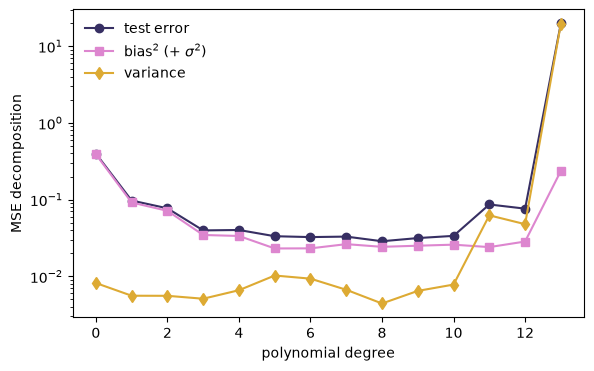

degree  0: error 0.3980  bias^2 0.3898  var 0.0082  sum 0.3980
degree  4: error 0.0401  bias^2 0.0336  var 0.0066  sum 0.0401
degree  8: error 0.0286  bias^2 0.0242  var 0.0044  sum 0.0286
degree 13: error 19.7520  bias^2 0.2367  var 19.5153  sum 19.7520


In [3]:
# Your code for exercise 3 here
np.random.seed(2026)
n, n_bootstraps, maxdegree = 40, 100, 13

x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=2026)

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)
for degree in range(maxdegree):
    model = make_pipeline(PolynomialFeatures(degree=degree),
                          LinearRegression(fit_intercept=False)) 
    y_pred = np.empty((y_test.shape[0], n_bootstraps))
    for i in range(n_bootstraps):
        x_, y_ = resample(x_train, y_train)
        y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

    # Expectations over training sets are averages along axis 1;
    # keepdims=True preserves the column shape and is essential
    # for the bias to come out right.
    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

BLUE, PINK, YELLOW = "#372F63", "#DD86CF", "#DDAA33" 


fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), error, "o-", color=BLUE, label="test error")
ax.plot(range(maxdegree), bias, "s-", color=PINK, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(range(maxdegree), variance, "d-", color=YELLOW, label="variance")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)
plt.show()

for d in (0, 4, 8, maxdegree - 1):
    print(f"degree {d:2d}: error {error[d]:.4f}  bias^2 {bias[d]:.4f}  "
          f"var {variance[d]:.4f}  sum {bias[d] + variance[d]:.4f}")

2. Discuss the figure in terms of Eq. (2.47): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?

The variance is mostly under $10^{-2}$ before the 11th degree before it starts dominating, meaning the model has become unstable, predicting a wide array of data. The bias on the other hand starts at about 5 and decreases as the degrees increase, before it starts climbing at 13 degrees. 
A model that is both stable and predicts well should be one with both good variance and bias. In this case, the optimal degree seems to be 8.

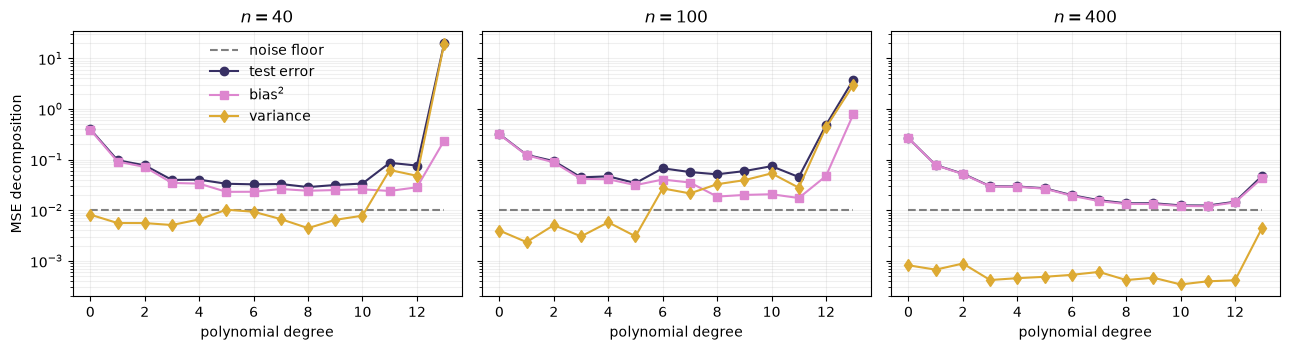

In [13]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance

noise = 0.1
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_, noise = noise)
    ax.plot(range(14), noise**2*np.ones(14), linestyle = 'dashed', label = 'noise floor', color= 'grey')
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=PINK, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.grid(alpha=0.2, which = 'both')
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.

The noise floor is present in all figures, but is clear that MSE when put together does not fall under.

As we increase the datapoints n to 100 and 400 so that the bootstraps have more data to work with, we see that the variance and bias behaves quite differently. 
For n=100, we see that both the variance and bias starts to rise at the 6th degree, before a local minimum at the 11th degree. The bias is slightly higher for the 11th degree, while it is clear that the variance is much lower at the 6th degree. The optimal degree seems to be the 5th degree.

For n=400, the variance remains consistently low before jumping a magnitude at the 6th degree. The bias shrinks one magnitude from the 1st degree to the 11th before doing a jump at the 13th. The model has a much larger amount of data to work with, making it easier to fit a model with consistently less variance. The bias follows a similar trend as both n=40 and n=100 do. The optimal degree here seems to be many, but perhaps the 11th is the best.

When comparing the three cases, the optimal degree differs. None quite agree even though the random sample generator is the same. 

In [52]:
degrees = [12]
# degrees = [0,1,2,3,4,5,6,7,8,9,10,11,12]
lams = np.logspace(-6,2,9)

err = np.zeros((lams.size, degrees[0]+1))
b2 = np.zeros((lams.size, degrees[0]+1))
var = np.zeros((lams.size, degrees[0]+1))

for deg in degrees:
    print(f"degree {deg}, n = 40, 100 bootstraps")
    print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}  {'MSE':>10}")
    for i in range(lams.size):
        if lams[i] == 0.0:
            mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),
                                        LinearRegression(fit_intercept=False))
        else:
            mk = lambda deg, lam=lams[i]: make_pipeline(PolynomialFeatures(degree=deg),
                                                    StandardScaler(),
                                                    Ridge(alpha=lam))
        err[i][:], b2[i][:], var[i][:] = bias_variance_sweep(n=40, maxdegree=deg + 1,
                                        make_model=mk)
        d = deg
        label = "OLS" if lams[i] == 0.0 else f"{lams[i]:g}"
        # print(f"{label:>8}  {err[d]:10.4f}  {b2[d]:10.4f}  {var[d]:10.4f}  {(var[d]**2+err[d]**2+b2[d]):10.4f}")

degree 12, n = 40, 100 bootstraps
  lambda       error      bias^2    variance         MSE


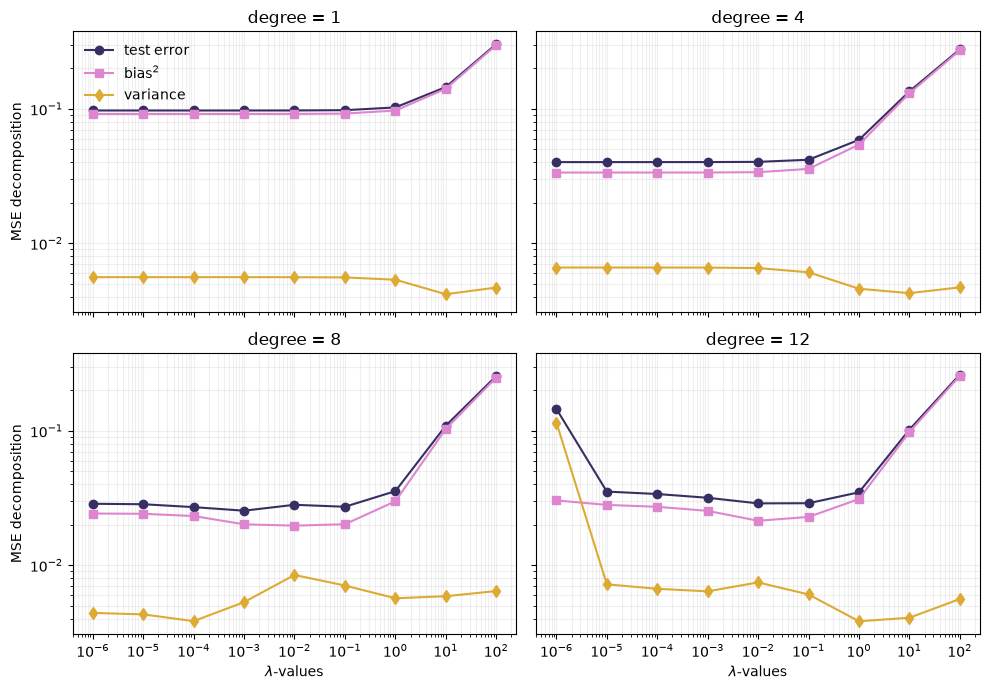

In [51]:
# Plot the bias-variance terms for each selected polynomial degree.
degrees = [1, 4, 8, 12]
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

for ax, degree in zip(axes.flat, degrees):
    ax.plot(lams, err[:, degree], "o-", color=BLUE, label="test error")
    ax.plot(lams, b2[:, degree], "s-", color=PINK, label=r"bias$^2$")
    ax.plot(lams, var[:, degree], "d-", color=YELLOW, label="variance")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"degree = {degree}")
    ax.grid(alpha=0.2, which="both")

for ax in axes[-1, :]:
    ax.set_xlabel(r"$\lambda$-values")
for ax in axes[:, 0]:
    ax.set_ylabel("MSE decomposition")
axes[0, 0].legend(frameon=False)
fig.tight_layout()
plt.show()

4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

As seen in the expression of the ridge estimator $\hat{\mathbf{\theta}}_{\mathrm{Ridge}}$, the estimator shrinks smoothly. Its shrinkage increases as $\sigma^2_i$ decreases. $$ \hat{\mathbf{\theta}}_{\mathrm{Ridge}}= \sum^{p-1}_{i=0}\frac{\sigma_i^2}{\sigma^2_i + \lambda}\frac{u_i^T y}{\sigma_i}v_i$$

The result is that some bias is traded for a large reduction in variance. This is especially apparent at the 12th degree, which is a much more complex model. If we compare this to the $\hat{\mathbf{\theta}}_{\mathrm{OLS}}$ MSEs where the variance grows significantly with the complexity of the model, the $\hat{\mathbf{\theta}}_{\mathrm{Ridge}}$ fares way better.

## Exercise 4: Cross-validation

Still with the same type of data, we now select models without consuming a
test set.

1. Use scikit-learn's (or perhaps write your own) $k$-fold cross-validation function: shuffle the data,
   split into $k$ folds, use each fold as test set once, and return the mean
   and standard deviation over folds of the test MSE. Do **not** use
   `cross_val_score` inside your own function.
2. Use it with $k = 5$ to compute the CV estimate of the MSE for OLS with
   polynomial degrees $0$ to $13$, and compare with the bootstrap analysis of
   exercise 3: do the two methods point to the same degree window?
3. For a degree-6 polynomial with Ridge regression on
   $y = 3x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$, $n=100$
   (Tuesday's Case 2), compute the CV MSE on
   `np.logspace(-3, 5, 100)` and find the optimal $\lambda$. Any
   scaling/preprocessing must be fitted **inside** each fold — explain in one
   or two sentences why.
4. Try $k = 5, 10$ and $n$ (leave-one-out). Comment on the stability of the
   selected $\lambda$ and on the computational cost.

In [ ]:
# Your code for exercise 4 here

## Exercise 5 (optional): error bars from the bootstrap

Use the bootstrap to attach uncertainties to fitted parameters, where the
analytical formula of exercise 1 can be checked — and where it cannot.

1. For OLS on a degree-3 polynomial fit of the exercise-3 data, bootstrap the
   training data 1000 times and histogram the resulting
   $\hat{\theta}_j^*$. Compare the bootstrap standard deviations with the
   analytical standard errors
   $\hat{\sigma}\sqrt{[(\boldsymbol{X}^T\boldsymbol{X})^{-1}]_{jj}}$ of
   Eq. (2.43).
2. Repeat for Lasso with a small penalty. Why is the bootstrap now the only
   option on the table? (Which assumption behind Eq. (2.43) fails?)

In [ ]:
# Your code for exercise 5 here

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 4 at midnight**. Collaboration is encouraged — list
your collaborators.